## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [ ]:
%load_ext autoreload
%autoreload 2

### Path to results directory 
from fluxy.config import initialize_settings
from fluxy.config import set_model_colors
from fluxy.io import read_flux, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.plots.mf_timeseries import plot_sites_timeseries
from fluxy.plots.mf_timeseries import plot_obs_modelled_separate


data_dir = r"C:\Users\coli\Documents\Data\paris"

### Set ppt_mode to True for bigger fonts
ppt_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['intem_name_edgar','elris_name_edgar','rhime_name_edgar'], # Standard run 
               'obs_selection' :['intem_name_edgar','intem_name_edgar_allobs',              # Effect of obs selection
                                 'elris_name_edgar','elris_name_edgar_allobs',
                                 'rhime_name_edgar','rhime_name_edgar_allobs'],
               'elris_edgar'    :['elris_name_edgar','elris_name_edgar_allobs',              # Effect of transport model and obs selection (ELRIS only)
                                  'elris_flex_edgar','elris_flex_edgar_allobs'],
               'wetcharts'      :['intem_name_wetcharts_31sites','elris_name_wetcharts_31sites',
                                  'rhime_name_wetcharts_31sites']
              }

###################################

s_data,m_data,m_colors,annotate_coords = initialize_settings(ppt_mode)

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [2]:
###################################
### edit variables in this block


species = 'hfc134a' #options for individual species, or 'all_hfc' or 'all_pfc'
models = experiments['std_run'] #if using 'all_hfc' or 'all_pfc' use basic model names (e.g. ['intem','elris','rhime']) and standard filenames will be used for each species
regions = ['GERMANY','UK','BENELUX','NW_EU2']
scale_co2eq = False
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

###################################

ds_all_flux_scaled = {}

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,s_data,m_data,
                                                     regions,start_date,end_date,
                                                     period_override=period_override)
else:
    ds_all_flux = read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

    for m in models:
        ds_all_flux_scaled[m] = slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                    scale_co2eq=scale_co2eq,convert_flux_units=False,species=species)[m]

model_colors = set_model_colors(models,m_colors)


Attempting to read data from intem_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\InTEM\hfc134a\InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized_hfc134a_yearly.nc
Done!

Attempting to read data from elris_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\ELRIS\hfc134a\ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_134a_yearly.nc
Done!

Attempting to read data from rhime_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\RHIME\hfc134a\RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_hfc134a_yearly.nc
Done!

Masking data from intem_name_edgar
Scaling intem_name_edgar country fluxes by 1000000.0

Masking data from elris_name_edgar
Scaling elris_name_edgar country fluxes by 1000000.0
Scaling covariance in elris_name_edgar by 1000000000000.0

Masking data from rhime_name_edgar
Scaling rhime_name_edgar country fluxes by 1000000.0


c:\Users\coli\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'countrynumber'} appear more than once in dims=('time', 'countrynumber', 'countrynumber'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
c:\Users\coli\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'countrynumber'} appear more than once in dims=('time', 'countrynumber', 'countrynumber'). We do not yet support duplicate dimension names, but we do allow initial construction of th

#### Timeseries of country fluxes:

BENELUX emissions are not present in elris_name_edgar. Considering covariance matrix and sum of individual countries: BEL-LUX-NLD.
NW_EU2 emissions are not present in elris_name_edgar. Considering covariance matrix and sum of individual countries: BEL-DEU-FRA-GBR-IRL-LUX-NLD.
NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


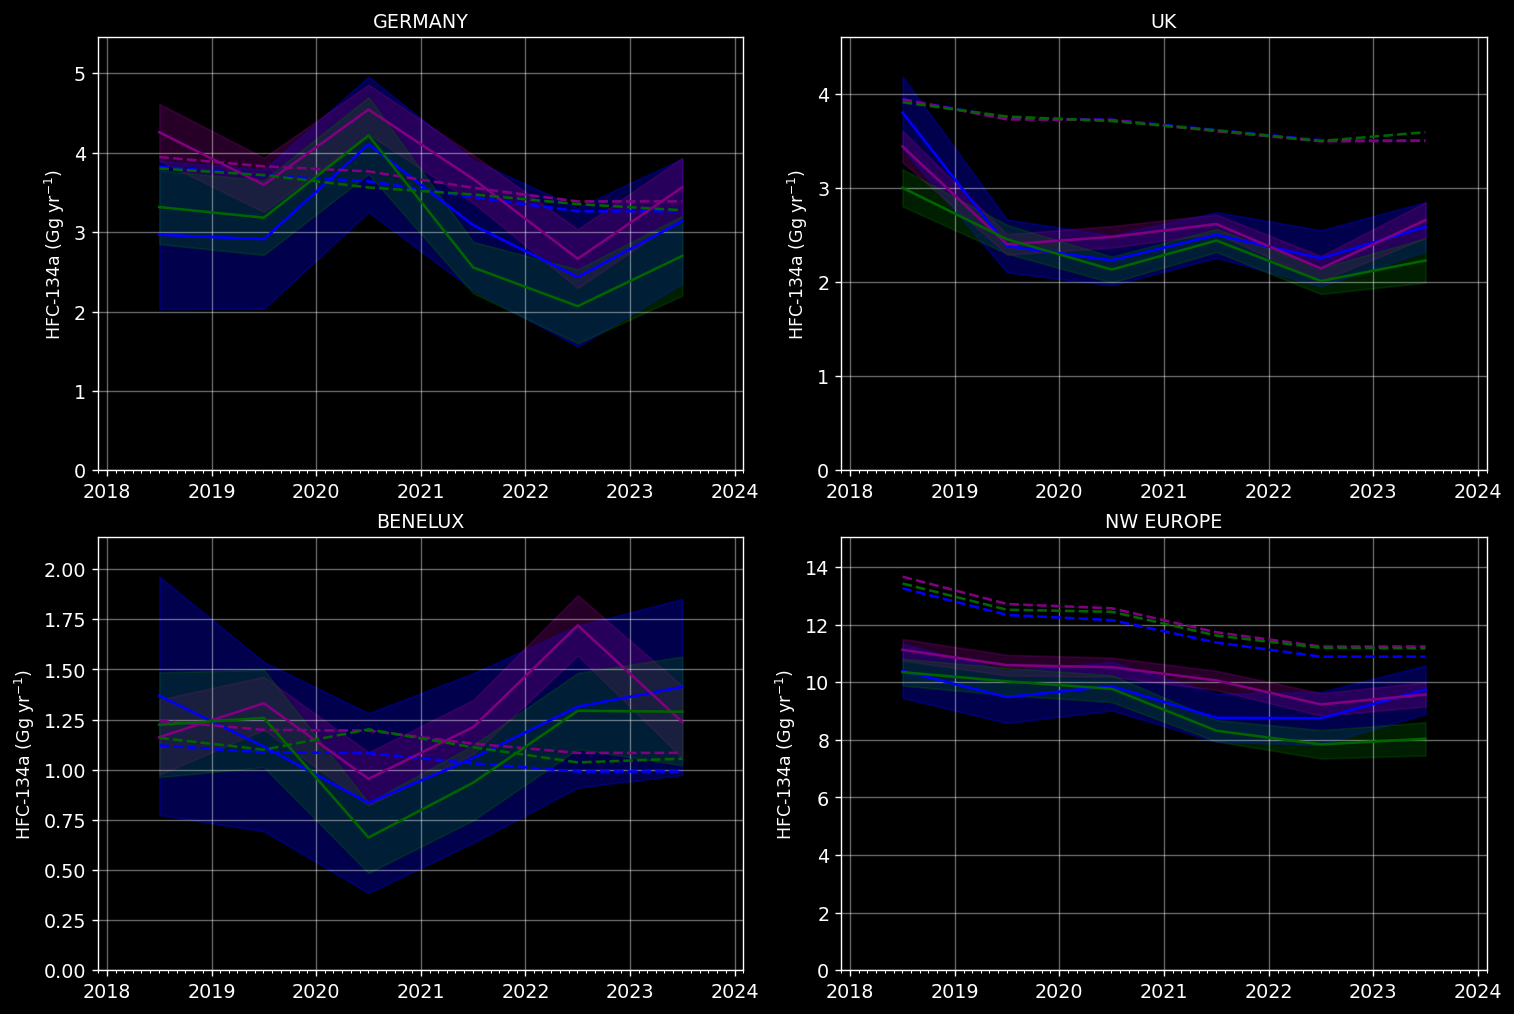

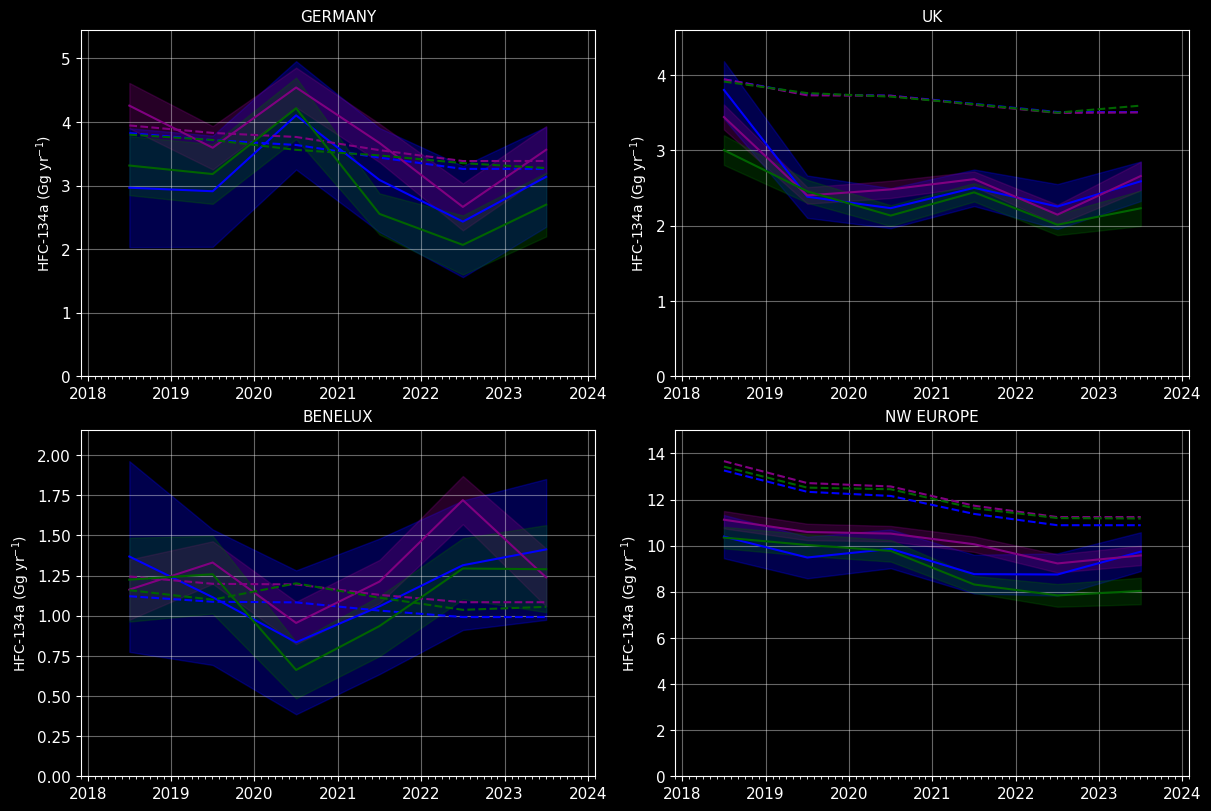

In [13]:
%matplotlib inline
###################################
### edit variables in this block
from fluxy.plots.flux_timeseries import plot_country_flux


plot_inventory = False
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = True #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_combined = False #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = False ##If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
###################################

fig = plot_country_flux(ds_all_flux_scaled,species,regions,
                             s_data,m_data,model_colors,start_date,end_date,ppt_mode,annex_mode,scale_co2eq,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,add_prior,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             resample=resample,resample_uncert_correlation=resample_uncert_correlation,
                             plot_resample_and_original=plot_resample_and_original,
                             period_override=period_override,rolling_mean=rolling_mean)

Save plot here:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/flux_country.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [16]:
###################################
### edit variables in this block
from fluxy.io import read_mf
from fluxy.operators.select import slice_mf


species = 'hfc134a' 
site = 'MHD'
models = experiments['std_run']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

model_colors = set_model_colors(models,m_colors)


Attempting to read data from intem_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\InTEM\hfc134a\InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized_hfc134a_yearly_concentrations.nc
Done!

Attempting to read data from elris_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\ELRIS\hfc134a\ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_134a_yearly_concentrations.nc
Done!

Attempting to read data from rhime_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\RHIME\hfc134a\RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_hfc134a_yearly_concentrations.nc
Done!

Masking data from intem_name_edgar
Scaling intem_name_edgar units by 1e-12

Masking data from elris_name_edgar
Scaling elris_name_edgar units by 1e-12

Masking data from rhime_name_edgar
Scaling rhime_name_edgar units by 1e-12


#### Plot timestamps with data at each site:

C:\Users\coli\Documents\PARIS_intercomparison_restructure\fluxy\plots\mf_timeseries.py:223: SyntaxWarning: invalid escape sequence '\m'
  xycoords='axes fraction',color=model_colors[m][var_colors[var]])
C:\Users\coli\Documents\PARIS_intercomparison_restructure\fluxy\plots\mf_timeseries.py:223: SyntaxWarning: invalid escape sequence '\s'
  xycoords='axes fraction',color=model_colors[m][var_colors[var]])
C:\Users\coli\Documents\PARIS_intercomparison_restructure\fluxy\plots\mf_timeseries.py:467: SyntaxWarning: invalid escape sequence '\m'
  xycoords='axes fraction',color=model_colors[m][var_colors[var]])
C:\Users\coli\Documents\PARIS_intercomparison_restructure\fluxy\plots\mf_timeseries.py:467: SyntaxWarning: invalid escape sequence '\s'
  xycoords='axes fraction',color=model_colors[m][var_colors[var]])
C:\Users\coli\Documents\PARIS_intercomparison_restructure\fluxy\plots\mf_timeseries.py:692: SyntaxWarning: invalid escape sequence '\m'
  xycoords='axes fraction',color=model_colors[m][var

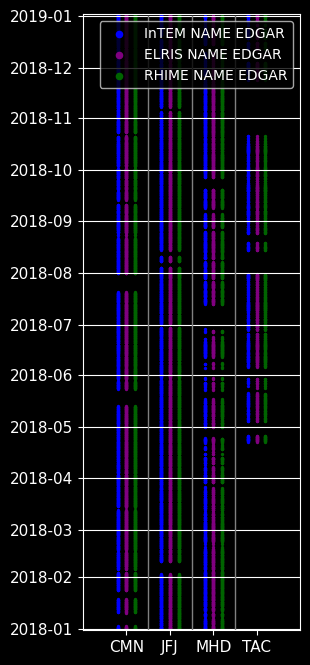

In [ ]:


fig = plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,model_colors,m_data)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


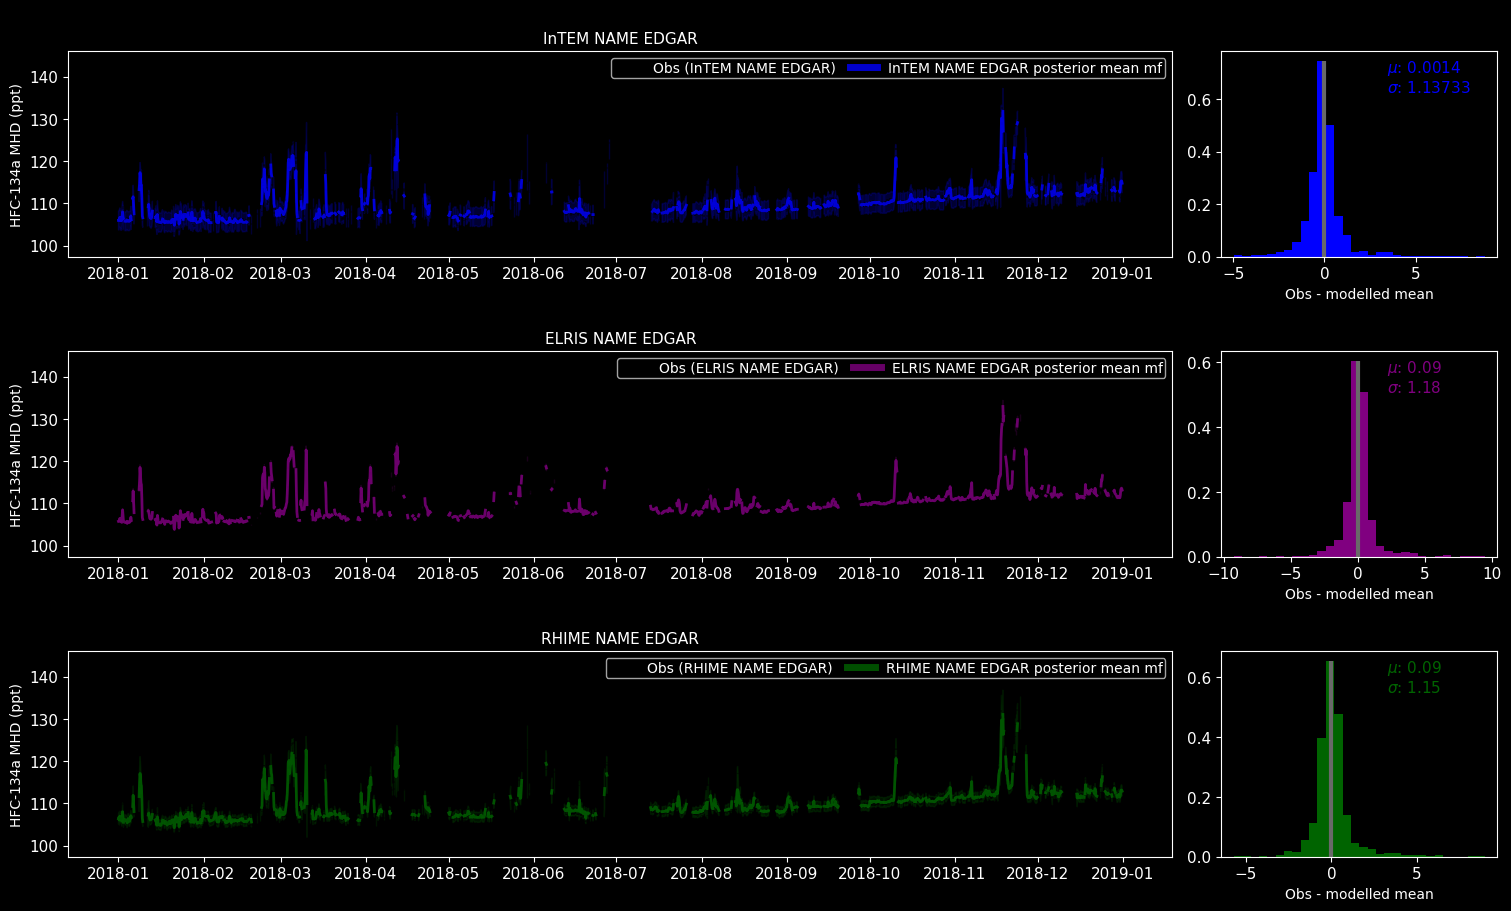

In [20]:


fig = plot_obs_modelled_separate(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yobs','Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_timeseries.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


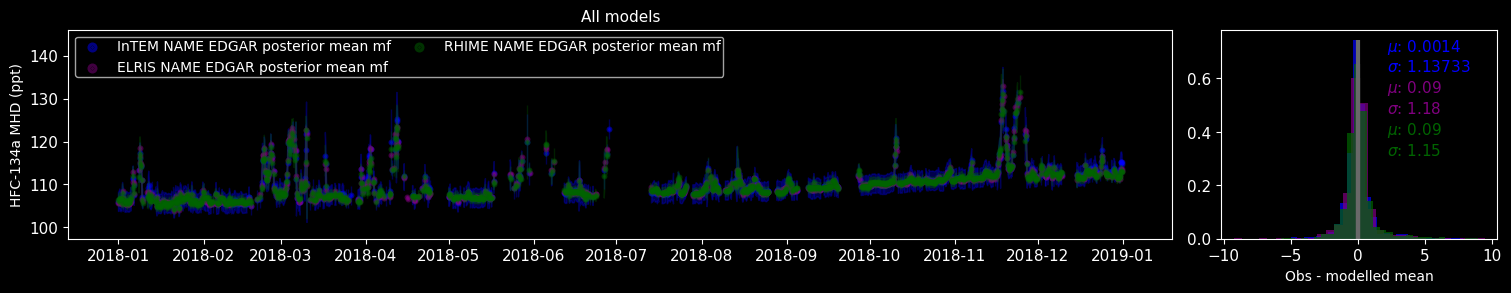

In [21]:
from fluxy.plots.mf_timeseries import plot_obs_modelled_together


fig = plot_obs_modelled_together(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


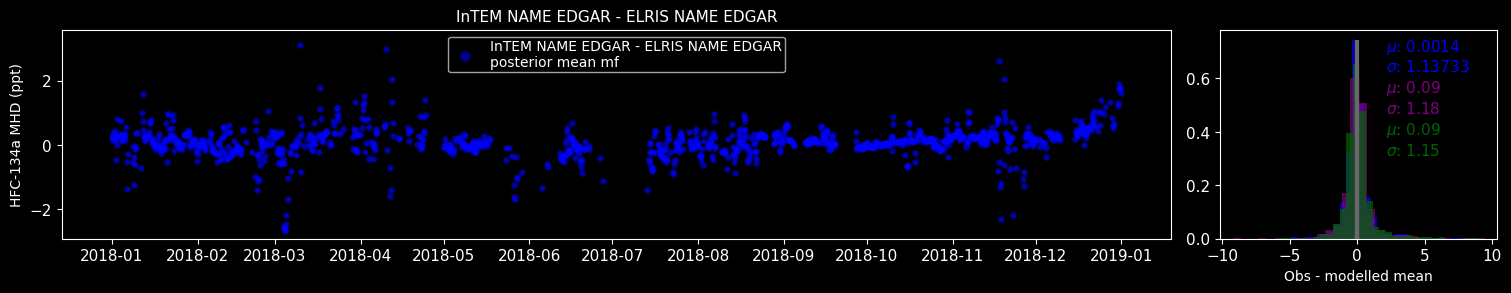

In [22]:
from fluxy.plots.mf_timeseries import plot_obs_diff


fig = plot_obs_diff(ds_all_mf_sliced,species,site,
                        model_colors,s_data,m_data,annotate_coords,ppt_mode,
                        include=['Yapost'],
                        diff_include=['Yapost'],
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:


Masking data from intem_name_edgar
Scaling intem_name_edgar units by 1e-12

Masking data from elris_name_edgar
Scaling elris_name_edgar units by 1e-12

Masking data from rhime_name_edgar
Scaling rhime_name_edgar units by 1e-12

Pearson correlation coefficient:
{'MHD': {'intem_name_edgar': 0.958,
         'elris_name_edgar': 0.954,
         'rhime_name_edgar': 0.958},
 'TAC': {'intem_name_edgar': 0.779,
         'elris_name_edgar': 0.778,
         'rhime_name_edgar': 0.797},
 'JFJ': {'intem_name_edgar': 0.825,
         'elris_name_edgar': 0.824,
         'rhime_name_edgar': 0.816},
 'CMN': {'intem_name_edgar': 0.724,
         'elris_name_edgar': 0.71,
         'rhime_name_edgar': 0.729}}

Normalised RMSE
{'MHD': {'intem_name_edgar': 0.01,
         'elris_name_edgar': 0.011,
         'rhime_name_edgar': 0.01},
 'TAC': {'intem_name_edgar': 0.043,
         'elris_name_edgar': 0.04,
         'rhime_name_edgar': 0.04},
 'JFJ': {'intem_name_edgar': 0.025,
         'elris_name_edgar': 0.024,


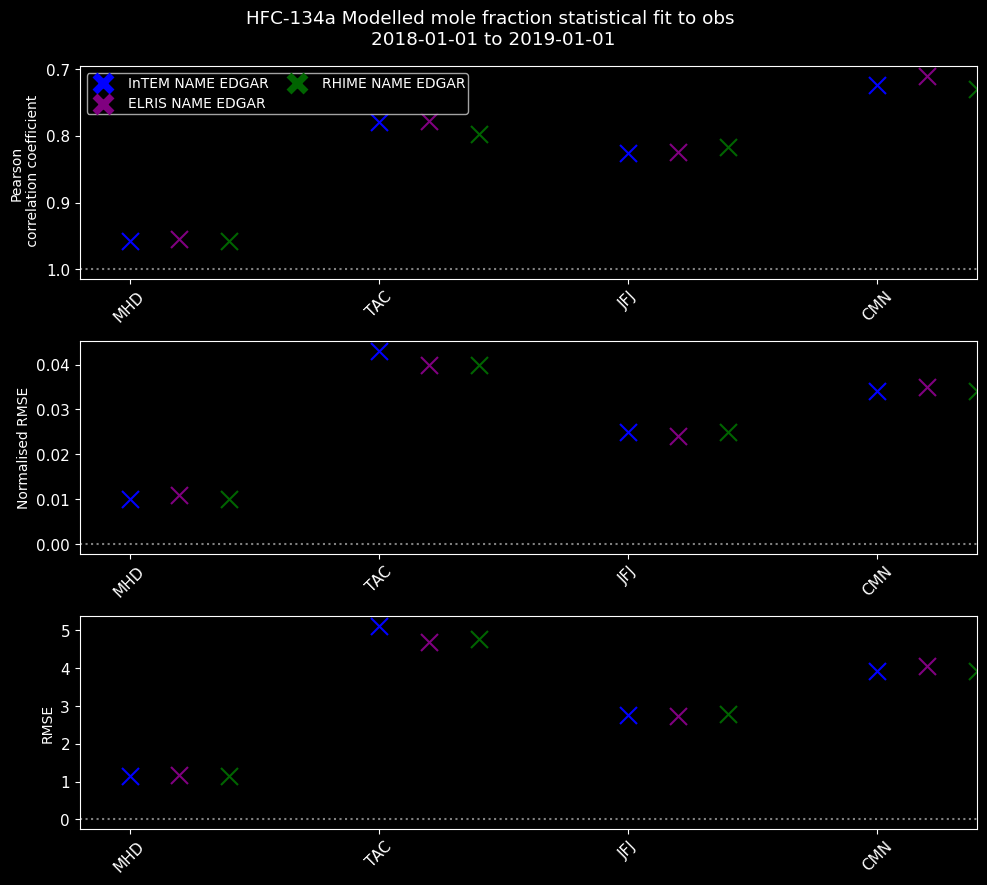

In [23]:
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf


ds_all_allsites = slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse,rmse = stats_mf(ds_all_allsites)

fig = plot_stats_mf(pearson,nrmse,rmse,species,
                         model_colors,s_data,m_data,
                         start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [24]:
###################################
### edit variables in this block
species = 'hfc134a'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2019-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = experiments['std_run']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
convert_flux_units = False #if true, convert molar flux to mass flux
###################################

ds_all_flux = read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                            scale_co2eq=False,convert_flux_units=convert_flux_units,species=species)[m]


Attempting to read data from intem_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\InTEM\hfc134a\InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized_hfc134a_yearly.nc
Done!

Attempting to read data from elris_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\ELRIS\hfc134a\ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_134a_yearly.nc
Done!

Attempting to read data from rhime_name_edgar
Reading data from: C:\Users\coli\Documents\Data\paris\RHIME\hfc134a\RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_hfc134a_yearly.nc
Done!

Masking data from intem_name_edgar
Scaling intem_name_edgar country fluxes by 1000000.0

Masking data from elris_name_edgar
Scaling elris_name_edgar country fluxes by 1000000.0
Scaling covariance in elris_name_edgar by 1000000000000.0

Masking data from rhime_name_edgar
Scaling rhime_name_edgar country fluxes by 1000000.0


c:\Users\coli\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'countrynumber'} appear more than once in dims=('time', 'countrynumber', 'countrynumber'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
c:\Users\coli\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'countrynumber'} appear more than once in dims=('time', 'countrynumber', 'countrynumber'). We do not yet support duplicate dimension names, but we do allow initial construction of th

##### Prior and posterior fluxes for all models:

No sites data available in elris_name_edgar attrs, so using site data from intem_name_edgar
No sites data available in rhime_name_edgar attrs, so using site data from intem_name_edgar

Plotting markers for: ['paris', 'london']
Edit lines below line 282 to change marker colour and size


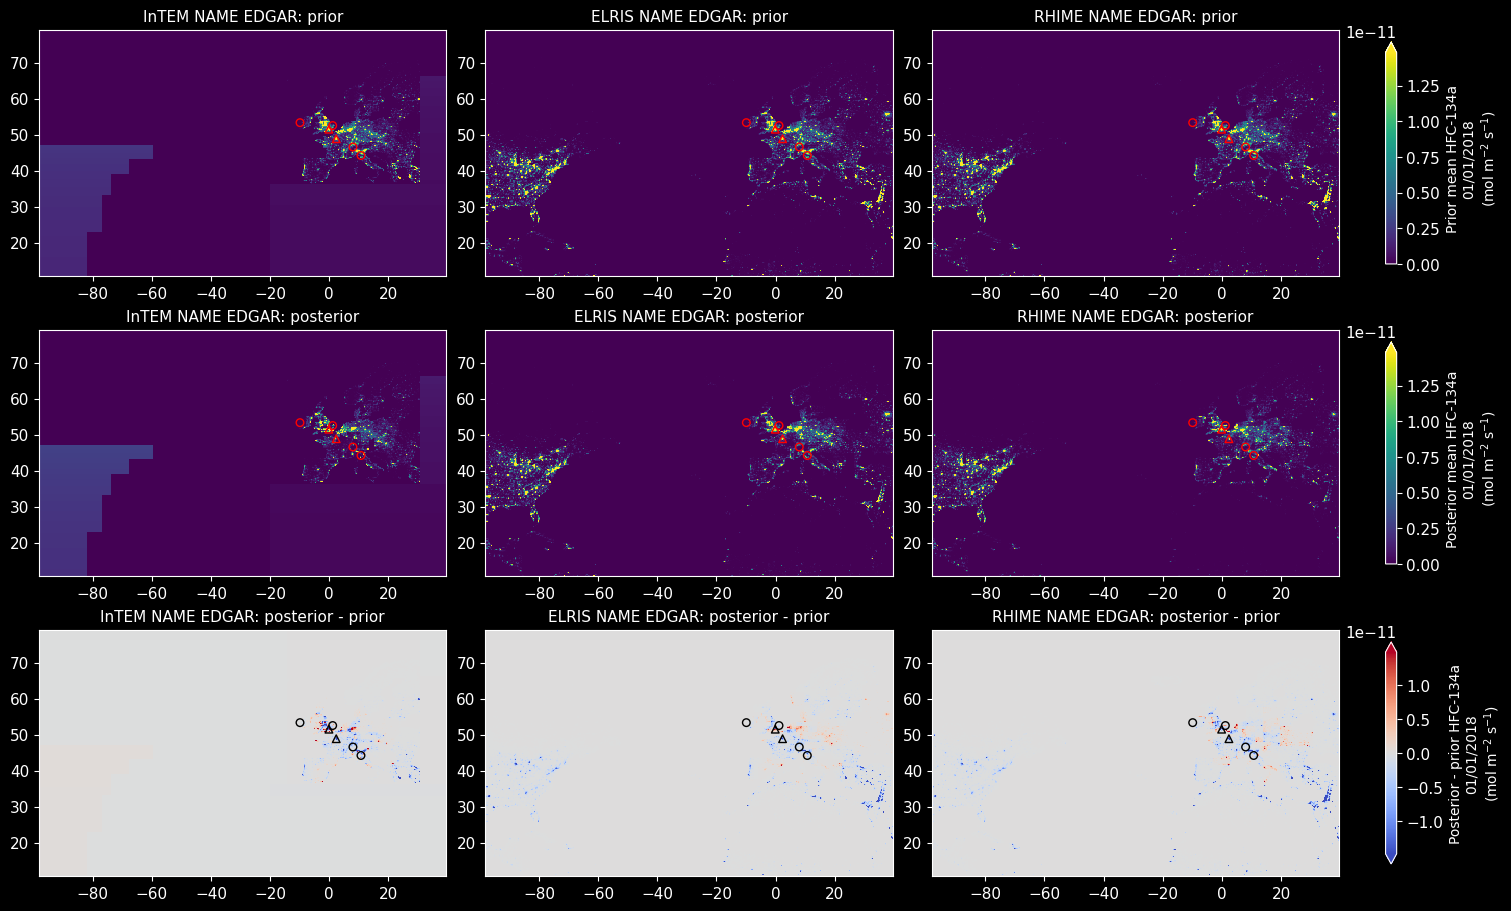

In [27]:
###################################
### edit variables in this block
from fluxy.plots.flux_map import plot_spatial_flux


plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NETHERLANDS, IRELAND, HUNGARY, NORWAY, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'coolwarm'
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
season = None #If specified plot the seasonal mean (only valable for monthly data). Options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'default'|'auto'
                        # 'default' = species_info default values and 'auto' = 99th percentile of flux_total_posterior
set_fluxlim_percentile = None # Percentile to use when setting the colorbar limits with 'auto' option.
plot_inversion_grid_flux = False #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
###################################

fig = plot_spatial_flux(ds_all_flux_scaled,species,plot_area,s_data,m_data,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=season,set_fluxlim=set_fluxlim,set_fluxlim_percentile=set_fluxlim_percentile,
                             plot_inversion_grid_flux=plot_inversion_grid_flux)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

No sites data available in elris_name_edgar attrs, so using site data from intem_name_edgar
No sites data available in rhime_name_edgar attrs, so using site data from intem_name_edgar

Plotting markers for: ['paris', 'london']
Edit lines below line 556 to change marker colour


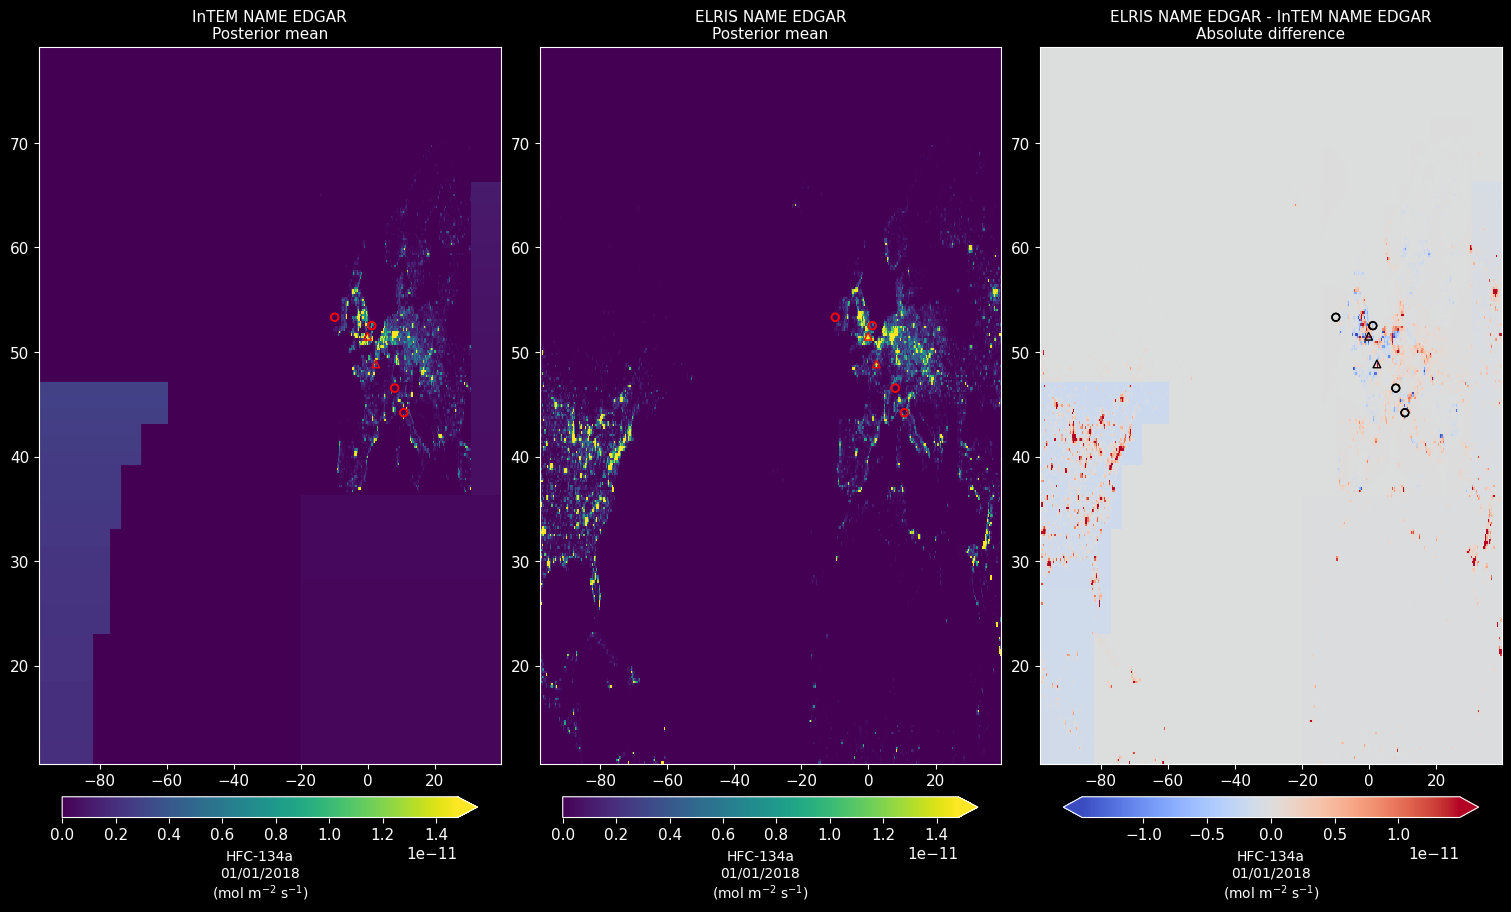

In [28]:
from fluxy.plots.flux_map import plot_spatial_flux_comparison


fig = plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,s_data,m_data,ppt_mode,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        plot_inversion_grid_flux=plot_inversion_grid_flux,
                                        set_fluxlim=set_fluxlim,
                                        set_fluxlim_percentile=set_fluxlim_percentile)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Plot prior, posterior or difference fluxes per time interval:

No sites data available in elris_name_edgar attrs, so using site data from intem_name_edgar
No sites data available in rhime_name_edgar attrs, so using site data from intem_name_edgar


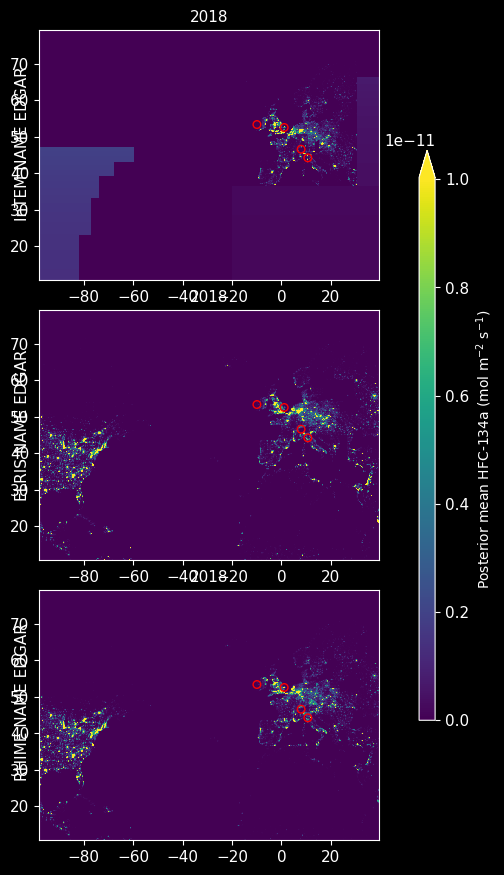

In [30]:
###################################
### edit variables in this block
from fluxy.plots.flux_map import plot_spatial_flux_per_timestamp


plot_area = 'CWEU'       #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NETHERLANDS, IRELAND, HUNGARY, NORWAY, NWEU, CWEU, EUROPE
cmap = 'viridis'         #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'floralwhite' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = 'year'  #time unit of the averaging period (options for 'year', 'month' and 'season')
                  #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 1  #number of time steps (in chop_by units) to use in the averaging
         #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'flux_total_posterior'  #variable to be plotted. Options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff', 'posterior_mean_diff'
plot_combined = False
plot_site_locations = True    #If True, adds markers to plots at locations of obs sites
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
plot_point_markers = None #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'default'|'auto'
                        # 'default' = species_info default values and 'auto' = 99th percentile of var
set_fluxlim_percentile = None # Percentile to use when setting the colorbar limits with 'auto' option.
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
plot_inversion_grid_flux = False #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
###################################

fig = plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,end_date,s_data,m_data,
                                            cmap=cmap,c_border=c_border,var=var,
                                            plot_combined=plot_combined,annex_mode=annex_mode,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers,set_fluxlim = set_fluxlim,
                                            set_fluxlim_percentile=set_fluxlim_percentile,plot_inversion_grid_flux=plot_inversion_grid_flux)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)